### 패션MNIST
- 구두, 가방, 옷 등의 이미지로 구성   
- class : 10개    
- 28*28 pixel = 784개의 Feature로 구성    
- sample수는 70000개 이다.    


In [ ]:
# !pip install tensorflow

  Using cached absl_py-2.3.1-py3-none-any.whl.metadata (3.3 kB)
  Using cached astunparse-1.6.3-py2.py3-none-any.whl.metadata (4.4 kB)
  Using cached flatbuffers-25.2.10-py2.py3-none-any.whl.metadata (875 bytes)
  Using cached gast-0.6.0-py3-none-any.whl.metadata (1.3 kB)
  Using cached google_pasta-0.2.0-py3-none-any.whl.metadata (814 bytes)
  Using cached libclang-18.1.1-1-py2.py3-none-macosx_11_0_arm64.whl.metadata (5.2 kB)
  Using cached opt_einsum-3.4.0-py3-none-any.whl.metadata (6.3 kB)
  Using cached termcolor-3.1.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached tensorboard-2.20.0-py3-none-any.whl.metadata (1.8 kB)
  Using cached keras-3.11.3-py3-none-any.whl.metadata (5.9 kB)
  Using cached tensorboard_data_server-0.7.2-py3-none-any.whl.metadata (1.1 kB)
  Using cached namex-0.1.0-py3-none-any.whl.metadata (322 bytes)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.4/200.4 MB 4.7 MB/s eta 0:00:0000:0100:02
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 2.2 MB/s eta

In [1]:
from tensorflow import keras

In [3]:
(train_input, train_target), (test_input, test_target) = \
                                keras.datasets.fashion_mnist.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


In [4]:
# train data
print(train_input.shape, train_target.shape)

(60000, 28, 28) (60000,)


In [5]:
# test data
print(test_input.shape, test_target.shape)

(10000, 28, 28) (10000,)


In [6]:
# train의 target data
train_target[:10]

array([9, 0, 0, 3, 0, 2, 7, 2, 5, 5], dtype=uint8)

- 0: 티셔츠
- 1: 바지
- 2: 스웨터
- 3: 드레스
- 4: 코트
- 5: 샌들
- 6: 셔츠
- 7: 스니커즈
- 8: 가방
- 9: 앵글부츠

In [ ]:
# !pip install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.1/8.1 MB 10.7 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.8/2.8 MB 9.0 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6/6 [matplotlib]6 [matplotlib]


In [8]:
# train의 input data의 모양 10개만 출력
import matplotlib.pyplot as plt

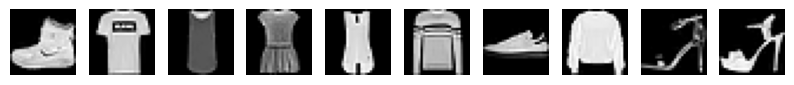

In [9]:
_, axs = plt.subplots(1, 10, figsize=(10,10))

for i in range(10):
  axs[i].imshow(train_input[i], cmap='gray')
  axs[i].axis('off')

plt.show()

In [10]:
# train_target의 종류 및 갯수 파악

import numpy as np

In [12]:
np.unique(train_target, return_counts=True)

(array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8),
 array([6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000, 6000]))

In [14]:
np.unique(train_target, return_counts=True)[1][1]

np.int64(6000)

---
### 로지스틱 회귀로 패션 아이템 분류

In [ ]:
train_scaled = train_input / 255.0   # 정규화,이미지는 최댓값이 255
train_scaled = train_scaled.reshape(-1, 28*28)   # (샘플수, 784)

In [19]:
train_scaled.shape

(60000, 784)

In [ ]:
# !pip install scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.7/8.7 MB 9.1 MB/s eta 0:00:00a 0:00:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 8.4 MB/s eta 0:00:0000:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4/4 [scikit-learn] [scikit-learn]


In [24]:
# 로지스틱 회귀 모델
from sklearn.model_selection import cross_validate
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(
  loss = "log_loss",
  max_iter= 5, 
  random_state=42
)

scores = cross_validate(
  sc,
  train_scaled,
  train_target,
  n_jobs=-1
)

print(np.mean(scores['test_score']))

/opt/anaconda3/envs/DeepLearning/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/envs/DeepLearning/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: divide by zero encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/DeepLearning/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: overflow encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/DeepLearning/lib/python3.10/site-packages/sklearn/utils/extmath.py:203: RuntimeWarning: invalid value encountered in matmul
  ret = a @ b
/opt/anaconda3/envs/DeepLearning/lib/python3.10/site-packages/sklearn/linear_model/_stochastic_gradient.py:726: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(
/opt/anaconda3/envs/De

0.8191833333333334


target별로 10개의 선형함수가 생성된다.    
target별로 1개의 Feature에 대해 10개의 가중치가 생성된다.   
판단은 확률값으로 한다.

#### 인공신경망
: 로지스틱 회귀와 비슷한 구조
- 가장 간단한 인공신경망은 입력층과 출력층이 1개씩 있는 구조
- 경사하강법을 사용한 로지스틱 회귀나 경사하강법을 사용한 선형회귀와 거의 같은 구조이다.

----
#### TensorFlow와 Keras
- Tensorflow는 2015년에 구글에서 Opensource로 발표
- 2016년 facebook에서 Pytorch.
- Tensorflow만 작업을 하게되면 너무 복잡한 코딩을 하게 된다.    
- 이를 기존방법(머신러닝)으로 간단하게 처리할 수 있게 만든것이 keras이다.
- Keras는 2015년(프랑스와숄레)에 Tensorflow보다 먼저 사용되고 있는 씨아노(GPU)라는 모듈을 기반으로 작성되었다.
- Keras 개발자가 구글에 입사해서 Tensorflow를 쉽게 처리할 수 있도록 제작
- 요즘에는 Tensorflow와 Keras는 동의어로 부른다.

---
### Keras Model 만들기

In [25]:
# Train data를 훈련과 검증으로 나누기
from sklearn.model_selection import train_test_split

train_scaled, val_scaled, train_target, val_target = \
                        train_test_split(
                          train_scaled,
                          train_target,
                          test_size=0.2,
                          random_state=42 # 선형회귀이기 때문에 stratify는 넣으면 안된다.
                        )

In [26]:
# Dimension
print(train_scaled.shape, train_target.shape)
print(val_scaled.shape, val_target.shape)

(48000, 784) (48000,)
(12000, 784) (12000,)


### Model 생성하기

In [28]:
from tensorflow.keras.layers import Input # 입력층을 표시하기

model = keras.Sequential()
model.add(
  Input(shape=(784,))
)
model.add(
  keras.layers.Dense(10, activation="softmax") # 10개로 출력할거다, 2진분류라면 : sigmoid
)

In [29]:
# 손실함수 설정

model.compile(
  loss='sparse_categorical_crossentropy',
  metrics=['accuracy']
)

# 정수로 구성된 target data를 사용하고 싶으면 loss함수명 앞에 sparse_를 붙인다.
# 이진 분류인 경우에는 binary_crossentropy
# 다중 분류인 경우에는 categorical_crossentropy를 사용한다.

### 모델 훈련

In [30]:
model.fit(
  train_scaled,
  train_target,
  epochs=5
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 1s 272us/step - accuracy: 0.7916 - loss: 0.6079
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step - accuracy: 0.8395 - loss: 0.4744
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 265us/step - accuracy: 0.8490 - loss: 0.4505
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 268us/step - accuracy: 0.8514 - loss: 0.4374
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 280us/step - accuracy: 0.8558 - loss: 0.4296


In [31]:
# 훈련 데이터 예측력
model.evaluate(train_scaled, train_target)

1500/1500 ━━━━━━━━━━━━━━━━━━━━ 0s 235us/step - accuracy: 0.8569 - loss: 0.4264


[0.42643114924430847, 0.8568541407585144]

In [32]:
# 검증 데이터 예측력
model.evaluate(val_scaled, val_target)

375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 256us/step - accuracy: 0.8445 - loss: 0.4498


[0.44977083802223206, 0.8445000052452087]

In [33]:
### test data 예측력 확인

In [35]:
test_scaled = test_input / 255.0   # 정규화,이미지는 최댓값이 255
test_scaled = test_scaled.reshape(-1, 28*28)   # (샘플수, 784)

test_scaled.shape

model.evaluate(test_scaled, test_target)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 259us/step - accuracy: 0.8380 - loss: 0.4788


[0.47876694798469543, 0.8379999995231628]